## Supp. Remote and Local-extended content start and end time

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import (
    save_remote_animal, load_remote_animal)

[2026-04-27 19:45:04,275][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[19:45:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:45:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:45:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:45:19][WARNING] Spyglass: Deprecation: this class has b

In [4]:
list_of_days_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [5]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta
from spyglass.shijiegu.changeOfMind_figures.supp_decode_t0t1 import (
    get_t0t1_animal, plot_histogram_t0t1)

In [6]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_start_end")

[19:45:37][INFO] Spyglass: Starting {'export_id': 107}
INFO:spyglass:Starting {'export_id': 107}


In [7]:
long_t0_animals = {}
remote_t0_animals = {}
for animal in list_of_days_animals:
    long_t0_animals[animal], remote_t0_animals[animal] = get_t0t1_animal(
        animal, list_of_days_animals[animal])

molly20220415_.nwb
molly20220416_.nwb
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb
molly20220420_.nwb
lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb
eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
julio20230731_.nwb
julio20230801_.nwb
julio20230802_.nwb
julio20230803_.nwb
julio20230804_.nwb
julio20230805_.nwb
julio20230806_.nwb
julio20230807_.nwb
julio20230808_.nwb
julio20230809_.nwb
julio20230810_.nwb
julio20230811_.nwb
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb


P-value for local extended content: 1.827671133284773e-12
P-value for remote content: 0.00021840451160574153
P-value for local extended content: 8.989636438279146e-41
P-value for remote content: 6.392861840407302e-20
P-value for local extended content: 3.814697265625e-06
P-value for remote content: 6.68231687036576e-10
P-value for local extended content: 0.003326416015625
P-value for remote content: 1.401159244350345e-09
P-value for local extended content: 9.511012532905987e-12
P-value for remote content: 1.6999371479476751e-15


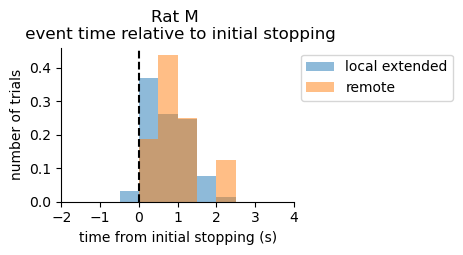

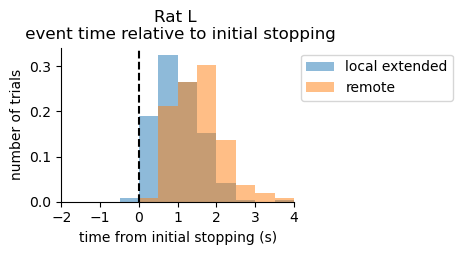

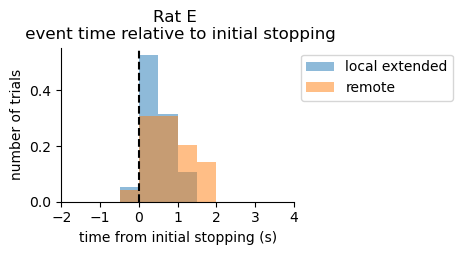

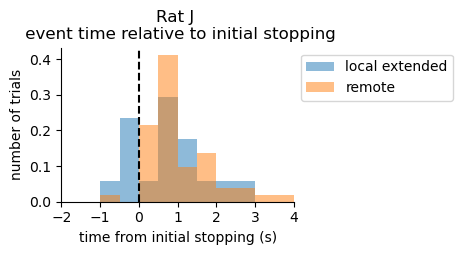

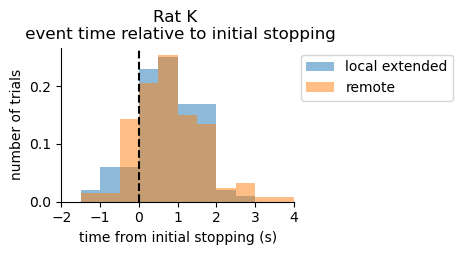

In [8]:
figure_outputfolder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp_decode/'
pvalue_long = {}
pvalue_remote = {}

for animal in list_of_days_animals:
    pvalue_long[animal], pvalue_remote[animal] = plot_histogram_t0t1(animal, 
                        long_t0_animals[animal], remote_t0_animals[animal],
                        output_folder = figure_outputfolder)

In [9]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_start_end")

## End